## Python Graph Gallery

#### Bubble Plot
https://python-graph-gallery.com/bubble-plot/


#### Animations using Matplotlib
https://matplotlib.org/stable/users/explain/animations/animations.html

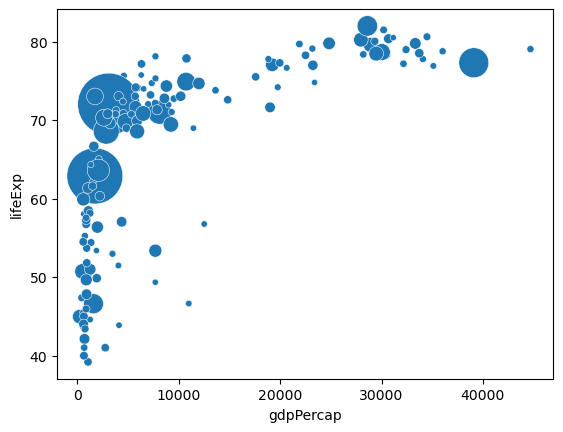

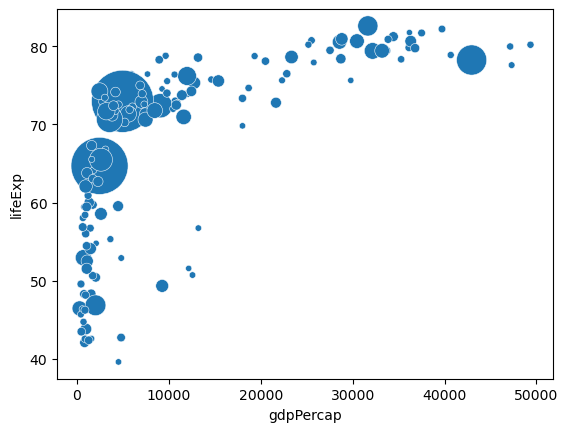

In [ ]:
#!pip install gapminder

# libraries
import matplotlib.pyplot as plt
import seaborn as sns
from gapminder import gapminder # data set

yrk  = [2002, 2007]

# data
for yr in yrk:
    # get the data
    data = gapminder.loc[gapminder.year == yr]

    # use the scatterplot function to build the bubble map
    sns.scatterplot(data = data, x = "gdpPercap", y = "lifeExp", size = "pop", legend = False, sizes = (20, 2000))

    # show the graph
    plt.show()

### Animations using Matplotlib
https://matplotlib.org/stable/users/explain/animations/animations.html

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation

#### Animation Classes

The animation process in Matplotlib can be thought of in 2 different ways:

FuncAnimation: Generate data for first frame and then modify this data for each frame to create an animated plot.

ArtistAnimation: Generate a list (iterable) of artists that will draw in each frame in the animation.

FuncAnimation is more efficient in terms of speed and memory as it draws an artist once and then modifies it. On the other hand ArtistAnimation is flexible as it allows any iterable of artists to be animated in a sequence.

##### FuncAnimation

The FuncAnimation class allows us to create an animation by passing a function that iteratively modifies the data of a plot. This is achieved by using the setter methods on various Artist (examples: Line2D, PathCollection, etc.). A usual FuncAnimation object takes a Figure that we want to animate and a function func that modifies the data plotted on the figure. It uses the frames parameter to determine the length of the animation. The interval parameter is used to determine time in milliseconds between drawing of two frames. Animating using FuncAnimation would usually follow the following structure:

Plot the initial figure, including all the required artists. Save all the artists in variables so that they can be updated later on during the animation.

Create an animation function that updates the data in each artist to generate the new frame at each function call.

Create a FuncAnimation object with the Figure and the animation function, along with the keyword arguments that determine the animation properties.

Use animation.Animation.save or pyplot.show to save or show the animation.

The update function uses the set_* function for different artists to modify the data. The following table shows a few plotting methods, the artist types they return and some methods that can be used to update them.

Plotting method

Artist

Set method

Axes.plot

lines.Line2D

set_data

Axes.scatter

collections.PathCollection

set_offsets

Axes.imshow

image.AxesImage

AxesImage.set_data

Axes.annotate

text.Annotation

update_positions

Axes.barh

patches.Rectangle

set_angle, set_bounds, set_height, set_width, set_x, set_y, set_xy

Axes.fill

patches.Polygon

set_xy

Axes.add_patch(patches.Ellipse)

patches.Ellipse

set_angle, set_center, set_height, set_width

Covering the set methods for all types of artists is beyond the scope of this tutorial but can be found in their respective documentations. An example of such update methods in use for Axes.scatter and Axes.plot is as follows.

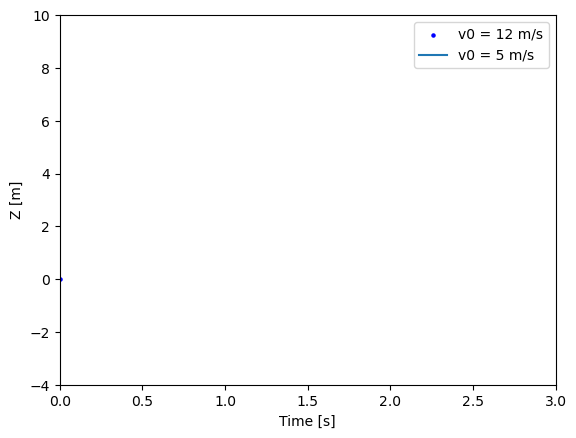

In [ ]:
fig, ax = plt.subplots()
t = np.linspace(0, 3, 40)
g = -9.81
v0 = 12
z = g * t**2 / 2 + v0 * t

v02 = 5
z2 = g * t**2 / 2 + v02 * t

scat = ax.scatter(t[0], z[0], c="b", s=5, label=f'v0 = {v0} m/s')
line2 = ax.plot(t[0], z2[0], label=f'v0 = {v02} m/s')[0]
ax.set(xlim=[0, 3], ylim=[-4, 10], xlabel='Time [s]', ylabel='Z [m]')
ax.legend()


def update(frame):
    # for each frame, update the data stored on each artist.
    x = t[:frame]
    y = z[:frame]
    # update the scatter plot:
    data = np.stack([x, y]).T
    scat.set_offsets(data)
    # update the line plot:
    line2.set_xdata(t[:frame])
    line2.set_ydata(z2[:frame])
    return (scat, line2)


ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
plt.show()

##### ArtistAnimation

ArtistAnimation can be used to generate animations if there is data stored on various different artists. This list of artists is then converted frame by frame into an animation. For example, when we use Axes.barh to plot a bar-chart, it creates a number of artists for each of the bar and error bars. To update the plot, one would need to update each of the bars from the container individually and redraw them. Instead, animation.ArtistAnimation can be used to plot each frame individually and then stitched together to form an animation. A barchart race is a simple example for this.

C:\Users\hilton.netta\AppData\Local\anaconda3\Lib\site-packages\matplotlib\animation.py:884: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


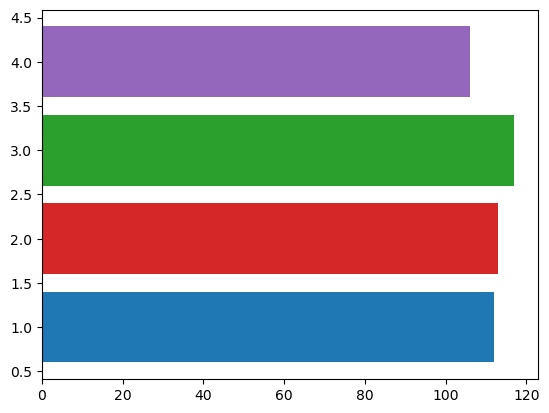

In [ ]:
fig, ax = plt.subplots()
rng = np.random.default_rng(19680801)
data = np.array([20, 20, 20, 20])
x = np.array([1, 2, 3, 4])

artists = []
colors = ['tab:blue', 'tab:red', 'tab:green', 'tab:purple']
for i in range(20):
    data += rng.integers(low=0, high=10, size=data.shape)
    container = ax.barh(x, data, color=colors)
    artists.append(container)


ani = animation.ArtistAnimation(fig=fig, artists=artists, interval=400)
plt.show()